In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Google Colab detected. Setting up GitHub repository...")
    if not os.path.exists('manero-panganiban-serafica'):
        !git clone https://github.com/kricme/manero-panganiban-serafica.git
    else:
        print("Repository already exists. Pulling latest updates from GitHub...")
        !git -C manero-panganiban-serafica pull

    # Navigate to the 07 folder
    if not os.getcwd().endswith('07 Forecasting'):
        %cd "manero-panganiban-serafica/07 Forecasting"
else:
    print("Local environment detected. Using local file paths.")

Google Colab detected. Setting up GitHub repository...
Repository already exists. Pulling latest updates from GitHub...
Already up to date.
/content/manero-panganiban-serafica/07 Forecasting


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

from scipy import stats

In [3]:
DATA_PATH = "../00 Cleaned Dataset/04 econ data with econobert results/withGDP_IRD_with_tone_dataset_jittered.csv"
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_COL = "Date"
Y_COL = "Interbank Call Loan Rate"

MACRO_COLS = [
    "Real GDP",
    "CPI",
    "Wholesale Price",
    "Industrial Production",
    "Intl Trade Merch Exports",
    "Intl Trade Merch Imports",
    "FX Rate",
]

TONE_MEAN = "tone_mean_jittered"
TONE_POS  = "pos_mean_jittered"
TONE_NEG  = "neg_mean_jittered"

In [4]:
# Forecast horizons
HORIZONS = [1, 2, 3, 4, 5, 6]

# Evaluation window for forecast ORIGINS t
EVAL_START = "2016-01-01"
EVAL_END   = "2019-12-31"

# Window sizes
ROLLING_W = 72  # months (e.g., 10 years)

# Forecast target: level or change
FORECAST_DIFFERENCES = False  # True => predict Δy_{t+h}

In [5]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred) -> float:
    return float(mean_absolute_error(y_true, y_pred))

In [6]:
@dataclass
class ModelConfig:
    ridge_alpha: float = 1.0
    lasso_alpha: float = 0.01
    enet_alpha: float = 0.01
    enet_l1_ratio: float = 0.5
    svr_C: float = 1.0
    svr_epsilon: float = 0.1
    svr_kernel: str = "rbf"

def build_models(cfg: ModelConfig) -> Dict[str, Pipeline]:
    return {
        "OLS": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=cfg.ridge_alpha))]),
        "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=cfg.lasso_alpha, max_iter=10000))]),
        "ElasticNet": Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=cfg.enet_alpha, l1_ratio=cfg.enet_l1_ratio, max_iter=10000))]),
        "SVR": Pipeline([("scaler", StandardScaler()), ("model", SVR(C=cfg.svr_C, epsilon=cfg.svr_epsilon, kernel=cfg.svr_kernel))]),
    }

MODEL_CFG = ModelConfig()
MODELS = build_models(MODEL_CFG)

In [7]:
TONE_SPECS = {
    "None": [],
    "ToneMean": [TONE_MEAN],
    "POSNEG": [TONE_POS, TONE_NEG],
    "NEG": [TONE_NEG],
}

def feature_cols_for(tone_spec: str) -> List[str]:
    return MACRO_COLS + TONE_SPECS[tone_spec]

In [8]:
df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

required = [DATE_COL, Y_COL] + MACRO_COLS + [TONE_MEAN, TONE_POS, TONE_NEG]
missing = [c for c in required if c not in df.columns]
if missing:
    raise SystemExit(f"Missing columns: {missing}\nFound columns: {list(df.columns)}")

if df[DATE_COL].duplicated().any():
    raise SystemExit("Duplicate dates found. Ensure one row per month.")

# numeric coercion
for c in [Y_COL] + MACRO_COLS + [TONE_MEAN, TONE_POS, TONE_NEG]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows:", len(df))
print("Date range:", df[DATE_COL].min().date(), "to", df[DATE_COL].max().date())

Rows: 228
Date range: 2001-04-01 to 2020-03-01


In [9]:
def make_direct_target(frame: pd.DataFrame, y_col: str, h: int, diff: bool) -> pd.Series:
    y_fwd = frame[y_col].shift(-h)
    if not diff:
        return y_fwd
    # Δy_{t+h} aligned at t
    return frame[y_col].shift(-h) - frame[y_col].shift(-(h-1))

def train_indices(scheme: str, t_idx: int, rolling_W: int) -> np.ndarray:
    if scheme == "expanding":
        start = 0
    elif scheme == "rolling":
        start = max(0, t_idx - rolling_W)
    else:
        raise ValueError("scheme must be 'rolling' or 'expanding'")
    return np.arange(start, t_idx)

In [10]:
def make_forecast_panel(df: pd.DataFrame) -> pd.DataFrame:
    eval_start = pd.to_datetime(EVAL_START)
    eval_end = pd.to_datetime(EVAL_END)

    schemes = ["rolling", "expanding"]
    rows = []

    for scheme in schemes:
        for h in HORIZONS:
            target_col = f"target_h{h}"
            df[target_col] = make_direct_target(df, Y_COL, h, FORECAST_DIFFERENCES)

            valid_target = df[target_col].notna()
            in_eval = (df[DATE_COL] >= eval_start) & (df[DATE_COL] <= eval_end)

            for tone_spec in TONE_SPECS.keys():
                feats = feature_cols_for(tone_spec)

                usable = valid_target.copy()
                for c in feats:
                    usable &= df[c].notna()

                origins = df.index[usable & in_eval].to_numpy()
                if len(origins) == 0:
                    continue

                X_all = df[feats].astype(float)
                y_all = df[target_col].astype(float)

                for model_name, pipe in MODELS.items():
                    for t_idx in origins:
                        tr_idx = train_indices(scheme, t_idx, ROLLING_W)

                        X_train = X_all.iloc[tr_idx]
                        y_train = y_all.iloc[tr_idx]
                        X_test = X_all.iloc[[t_idx]]
                        y_true = float(y_all.iloc[t_idx])

                        if len(X_train) < max(24, len(feats) + 5):
                            continue

                        pipe.fit(X_train, y_train)
                        y_pred = float(pipe.predict(X_test)[0])

                        rows.append({
                            "window_scheme": scheme,
                            "horizon_h": int(h),
                            "model": model_name,
                            "tone_spec": tone_spec,
                            "origin_date": df.loc[t_idx, DATE_COL],
                            "y_true": y_true,
                            "y_pred": y_pred,
                            "error": y_true - y_pred,
                        })

    panel = pd.DataFrame(rows).sort_values(
        ["window_scheme", "horizon_h", "model", "tone_spec", "origin_date"]
    ).reset_index(drop=True)

    panel.to_csv(os.path.join(OUT_DIR, "oos_forecast_panel.csv"), index=False)
    print("Saved: oos_forecast_panel.csv")
    return panel

forecast_panel = make_forecast_panel(df)
forecast_panel.head()

Saved: oos_forecast_panel.csv


,window_scheme,horizon_h,model,tone_spec,origin_date,y_true,y_pred,error
0,expanding,1,ElasticNet,NEG,2016-01-01,2.525040,3.454416,-0.929376
1,expanding,1,ElasticNet,NEG,2016-02-01,2.519768,3.617664,-1.097895
2,expanding,1,ElasticNet,NEG,2016-03-01,2.528319,3.220880,-0.692561
3,expanding,1,ElasticNet,NEG,2016-04-01,2.523848,3.626085,-1.102237
4,expanding,1,ElasticNet,NEG,2016-05-01,2.525338,3.889900,-1.364562


In [11]:
def aligned_accuracy(panel: pd.DataFrame) -> pd.DataFrame:
    out = []

    for (scheme, h, model), g in panel.groupby(["window_scheme", "horizon_h", "model"]):
        base = g[g["tone_spec"] == "None"][["origin_date", "y_true", "y_pred"]].rename(columns={"y_pred":"y_pred_none"})
        if base.empty:
            continue

        # compute naive benchmark on the SAME origin set as baseline (persistence)
        # If forecasting levels: yhat_{t+h} = y_t  -> we don't have y_t in panel, so we approximate via:
        # naive on y_true isn't available unless we rebuild; so we omit naive here for alignment purity.
        # If you want naive, we can rebuild it from df separately.

        for tone_spec in TONE_SPECS.keys():
            alt = g[g["tone_spec"] == tone_spec][["origin_date", "y_pred"]].rename(columns={"y_pred":"y_pred_alt"})
            merged = base.merge(alt, on="origin_date", how="inner")
            if len(merged) < 10:
                continue

            y = merged["y_true"].to_numpy()
            e_none = y - merged["y_pred_none"].to_numpy()
            e_alt  = y - merged["y_pred_alt"].to_numpy()

            rmse_none = float(np.sqrt(np.mean(e_none**2)))
            rmse_alt  = float(np.sqrt(np.mean(e_alt**2)))
            mae_none  = float(np.mean(np.abs(e_none)))
            mae_alt   = float(np.mean(np.abs(e_alt)))

            pct_drmse = np.nan
            if tone_spec != "None" and rmse_none > 0:
                pct_drmse = (rmse_none - rmse_alt) / rmse_none * 100.0

            out.append({
                "window_scheme": scheme,
                "horizon_h": int(h),
                "model": model,
                "tone_spec": tone_spec,
                "n_common": len(merged),
                "rmse_none_aligned": rmse_none,
                "rmse_aligned": rmse_alt,
                "mae_none_aligned": mae_none,
                "mae_aligned": mae_alt,
                "pct_dRMSE_vs_none": pct_drmse,
            })

    res = pd.DataFrame(out).sort_values(
        ["window_scheme","horizon_h","model","tone_spec"]
    ).reset_index(drop=True)

    res.to_csv(os.path.join(OUT_DIR, "aligned_accuracy.csv"), index=False)
    print("Saved: aligned_accuracy.csv")
    return res

acc = aligned_accuracy(forecast_panel)
acc.head(20)

Saved: aligned_accuracy.csv


,window_scheme,horizon_h,model,tone_spec,n_common,rmse_none_aligned,rmse_aligned,mae_none_aligned,mae_aligned,pct_dRMSE_vs_none
0,expanding,1,ElasticNet,NEG,48,1.019424,1.023604,0.930558,0.936651,-0.410077
1,expanding,1,ElasticNet,None,48,1.019424,1.019424,0.930558,0.930558,NaN
2,expanding,1,ElasticNet,POSNEG,48,1.019424,1.122344,0.930558,1.020393,-10.095951
3,expanding,1,ElasticNet,ToneMean,48,1.019424,1.036922,0.930558,0.946838,-1.716482
4,expanding,1,Lasso,NEG,48,1.019285,1.023458,0.932195,0.938087,-0.409372
5,expanding,1,Lasso,None,48,1.019285,1.019285,0.932195,0.932195,NaN
6,expanding,1,Lasso,POSNEG,48,1.019285,1.119710,0.932195,1.020140,-9.852435
7,expanding,1,Lasso,ToneMean,48,1.019285,1.035813,0.932195,0.947660,-1.621531
8,expanding,1,OLS,NEG,48,1.022482,1.027104,0.928243,0.934861,-0.451999
9,expanding,1,OLS,None,48,1.022482,1.022482,0.928243,0.928243,NaN


In [12]:
def _newey_west_var_mean(x: np.ndarray, lag: int) -> float:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    T = len(x)
    if T < 3:
        return np.nan
    x = x - x.mean()

    gamma0 = np.dot(x, x) / T
    var = gamma0

    L = min(lag, T-1)
    for l in range(1, L+1):
        w = 1.0 - l/(L+1.0)
        gam = np.dot(x[l:], x[:-l]) / T
        var += 2.0 * w * gam

    return var / T  # variance of the mean

In [13]:
def diebold_mariano(e1: np.ndarray, e2: np.ndarray, h: int, power: int = 2):
    mask = ~np.isnan(e1) & ~np.isnan(e2)
    e1, e2 = e1[mask], e2[mask]
    if len(e1) < 10:
        return np.nan, np.nan, np.nan

    d = (np.abs(e1)**power) - (np.abs(e2)**power)
    mean_d = d.mean()

    lag = max(0, h-1)
    var_mean = _newey_west_var_mean(d, lag=lag)
    if not np.isfinite(var_mean) or var_mean <= 0:
        return np.nan, np.nan, mean_d

    stat = mean_d / np.sqrt(var_mean)
    p_two = 2*(1 - stats.norm.cdf(np.abs(stat)))
    return stat, p_two, mean_d

def clark_west(e_small: np.ndarray, e_big: np.ndarray, y_true: np.ndarray, h: int):
    mask = ~np.isnan(e_small) & ~np.isnan(e_big) & ~np.isnan(y_true)
    e_small, e_big, y_true = e_small[mask], e_big[mask], y_true[mask]
    if len(y_true) < 10:
        return np.nan, np.nan, np.nan

    yhat_small = y_true - e_small
    yhat_big   = y_true - e_big

    f = (e_small**2) - (e_big**2) + (yhat_big - yhat_small)**2
    mean_f = f.mean()

    lag = max(0, h-1)
    var_mean = _newey_west_var_mean(f, lag=lag)
    if not np.isfinite(var_mean) or var_mean <= 0:
        return np.nan, np.nan, mean_f

    stat = mean_f / np.sqrt(var_mean)
    p_one = 1 - stats.norm.cdf(stat)  # one-sided: improvement => stat large
    return stat, p_one, mean_f

In [14]:
def significance(panel: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (scheme, h, model), g in panel.groupby(["window_scheme","horizon_h","model"]):
        base = g[g["tone_spec"]=="None"][["origin_date","y_true","y_pred"]].rename(columns={"y_pred":"y_pred_none"})
        if base.empty:
            continue

        for tone_spec in [s for s in TONE_SPECS.keys() if s != "None"]:
            alt = g[g["tone_spec"]==tone_spec][["origin_date","y_pred"]].rename(columns={"y_pred":"y_pred_alt"})
            merged = base.merge(alt, on="origin_date", how="inner")
            if len(merged) < 10:
                continue

            y = merged["y_true"].to_numpy()
            e_none = y - merged["y_pred_none"].to_numpy()
            e_alt  = y - merged["y_pred_alt"].to_numpy()

            cw_stat, cw_p1, cw_mean = clark_west(e_none, e_alt, y, int(h))
            dm_stat, dm_p2, dm_mean = diebold_mariano(e_none, e_alt, int(h), power=2)

            msfe_none = float(np.mean(e_none**2))
            msfe_alt  = float(np.mean(e_alt**2))

            out.append({
                "window_scheme": scheme,
                "horizon_h": int(h),
                "model": model,
                "tone_spec": tone_spec,
                "n_common": len(merged),
                "MSFE_none": msfe_none,
                "MSFE_tone": msfe_alt,
                "MSFE_gain": msfe_none - msfe_alt,
                "CW_stat": cw_stat,
                "CW_p_one_sided": cw_p1,
                "DM_stat": dm_stat,
                "DM_p_two_sided": dm_p2,
            })

    res = pd.DataFrame(out).sort_values(
        ["window_scheme","horizon_h","model","tone_spec"]
    ).reset_index(drop=True)

    res.to_csv(os.path.join(OUT_DIR, "significance_cw_dm.csv"), index=False)
    print("Saved: significance_cw_dm.csv")
    return res

sig = significance(forecast_panel)
sig.head(20)

Saved: significance_cw_dm.csv


,window_scheme,horizon_h,model,tone_spec,n_common,MSFE_none,MSFE_tone,MSFE_gain,CW_stat,CW_p_one_sided,DM_stat,DM_p_two_sided
0,expanding,1,ElasticNet,NEG,48,1.039224,1.047765,-0.008541,-0.641246,0.739319,-0.749289,0.453683
1,expanding,1,ElasticNet,POSNEG,48,1.039224,1.259656,-0.220432,-2.714189,0.996678,-3.103612,0.001912
2,expanding,1,ElasticNet,ToneMean,48,1.039224,1.075207,-0.035982,-2.279073,0.988669,-2.365164,0.018022
3,expanding,1,Lasso,NEG,48,1.038942,1.047466,-0.008524,-0.722256,0.764931,-0.818230,0.413226
4,expanding,1,Lasso,POSNEG,48,1.038942,1.253750,-0.214807,-2.702453,0.996559,-3.086768,0.002023
5,expanding,1,Lasso,ToneMean,48,1.038942,1.072909,-0.033967,-2.257043,0.987997,-2.338888,0.019341
6,expanding,1,OLS,NEG,48,1.045470,1.054942,-0.009472,-0.606881,0.728035,-0.730773,0.464918
7,expanding,1,OLS,POSNEG,48,1.045470,1.266972,-0.221501,-2.632948,0.995768,-3.039888,0.002367
8,expanding,1,OLS,ToneMean,48,1.045470,1.080348,-0.034878,-2.220804,0.986818,-2.307388,0.021033
9,expanding,1,Ridge,NEG,48,1.042033,1.051230,-0.009197,-0.602498,0.726579,-0.724153,0.468972


In [15]:
# merge aligned accuracy with CW p-values (for tone specs)
acc2 = acc.merge(
    sig[["window_scheme","horizon_h","model","tone_spec","CW_p_one_sided","MSFE_gain"]],
    on=["window_scheme","horizon_h","model","tone_spec"],
    how="left"
)
acc2["CW_sig_5pct"] = acc2["CW_p_one_sided"] < 0.05

# Best tone spec per (scheme, horizon, model) among tone candidates
tone_only = acc2[acc2["tone_spec"] != "None"].copy()
idx = tone_only.groupby(["window_scheme","horizon_h","model"])["rmse_aligned"].idxmin()
best_tone_per_model = tone_only.loc[idx].sort_values(["window_scheme","horizon_h","model"])
best_tone_per_model.to_csv(os.path.join(OUT_DIR, "best_tone_per_model_per_h.csv"), index=False)

# Best (model, tone_spec) overall per (scheme, horizon)
idx2 = acc2.groupby(["window_scheme","horizon_h"])["rmse_aligned"].idxmin()
best_combo_per_h = acc2.loc[idx2].sort_values(["window_scheme","horizon_h"])
best_combo_per_h.to_csv(os.path.join(OUT_DIR, "best_combo_per_h.csv"), index=False)

best_tone_per_model.head(20), best_combo_per_h

(   window_scheme  horizon_h       model tone_spec  n_common  \
 0      expanding          1  ElasticNet       NEG        48   
 4      expanding          1       Lasso       NEG        48   
 8      expanding          1         OLS       NEG        48   
 12     expanding          1       Ridge       NEG        48   
 19     expanding          1         SVR  ToneMean        48   
 20     expanding          2  ElasticNet       NEG        48   
 24     expanding          2       Lasso       NEG        48   
 28     expanding          2         OLS       NEG        48   
 32     expanding          2       Ridge       NEG        48   
 39     expanding          2         SVR  ToneMean        48   
 40     expanding          3  ElasticNet       NEG        48   
 44     expanding          3       Lasso       NEG        48   
 48     expanding          3         OLS       NEG        48   
 52     expanding          3       Ridge       NEG        48   
 59     expanding          3         SVR

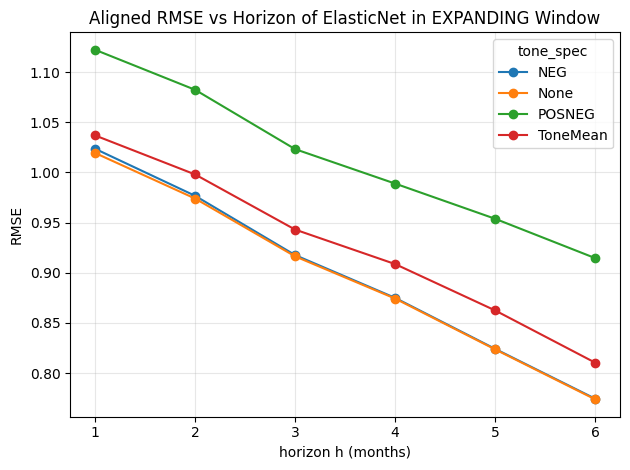

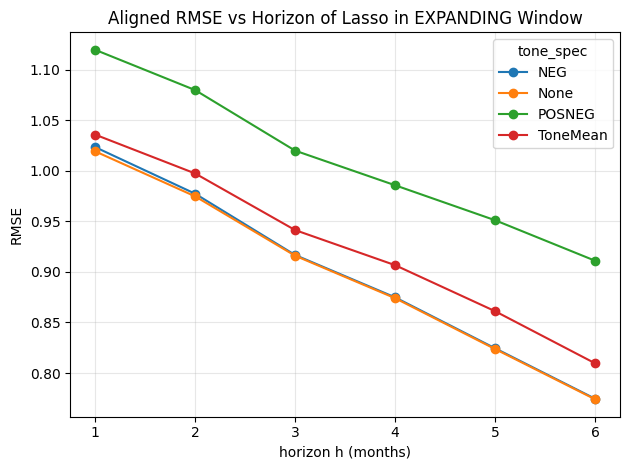

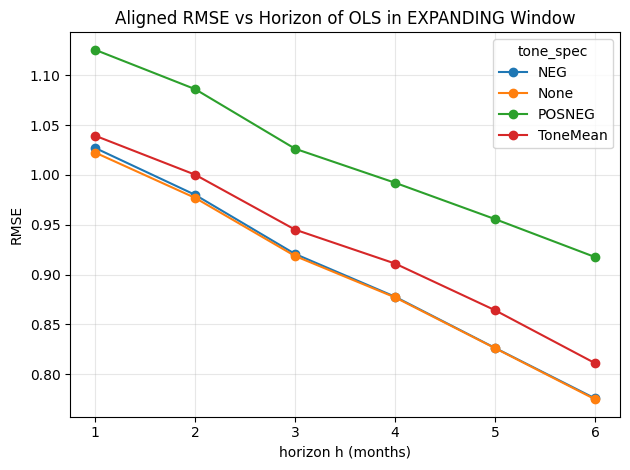

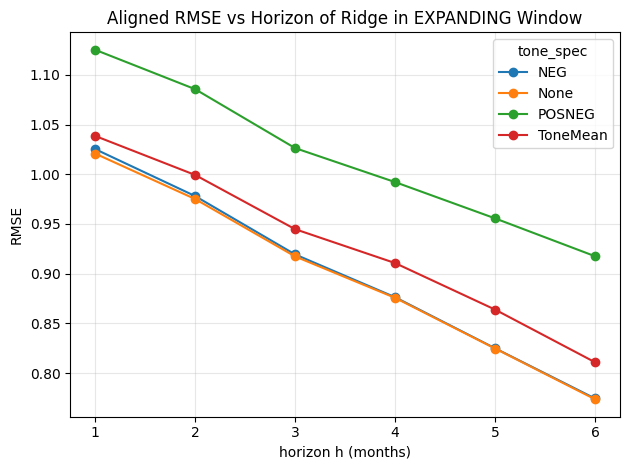

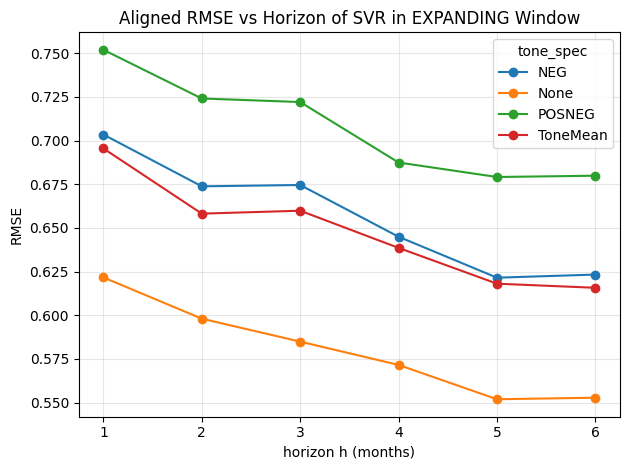

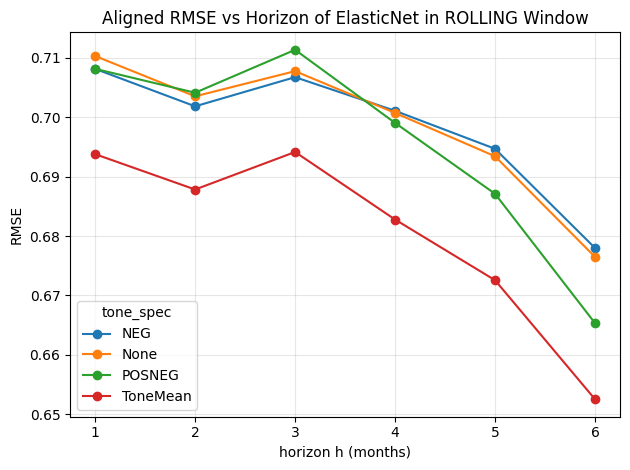

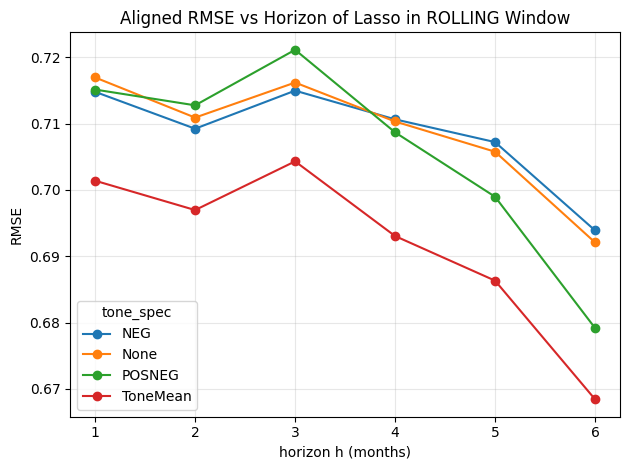

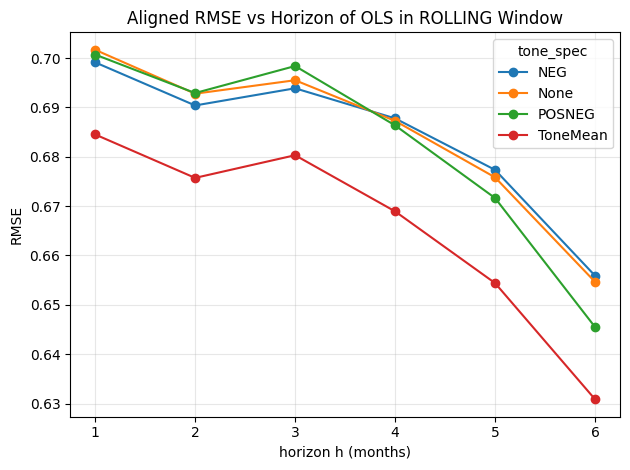

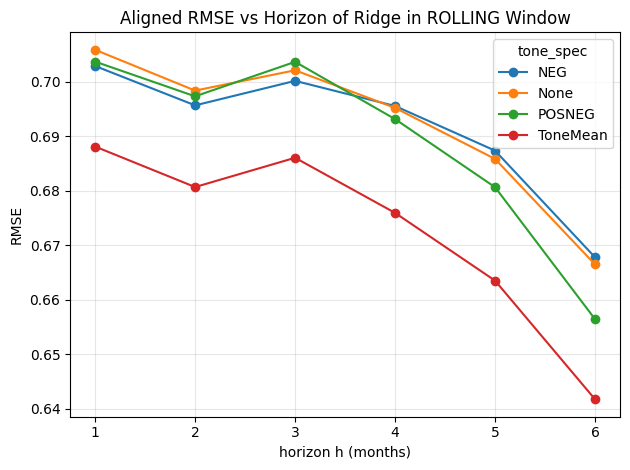

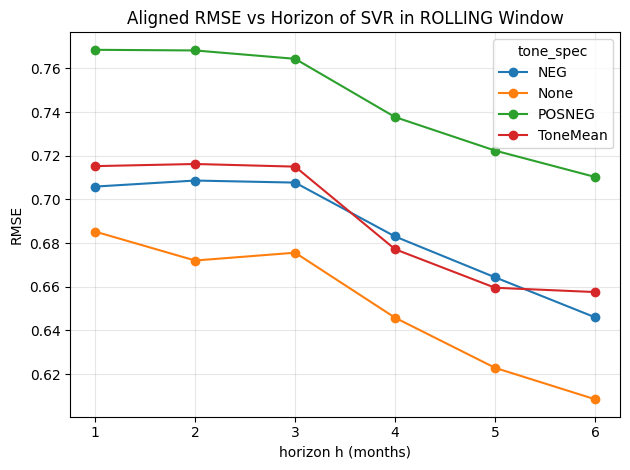

In [16]:
def plot_rmse_vs_horizon(acc2: pd.DataFrame):
    for scheme in acc2["window_scheme"].unique():
        sub = acc2[acc2["window_scheme"] == scheme]
        for model in sub["model"].unique():
            dfm = sub[sub["model"] == model].pivot_table(
                index="horizon_h", columns="tone_spec", values="rmse_aligned"
            ).sort_index()

            ax = dfm.plot(marker="o")
            ax.set_title(f"Aligned RMSE vs Horizon of {model} in {scheme.upper()} Window")
            ax.set_xlabel("horizon h (months)")
            ax.set_ylabel("RMSE")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            filename = f"rmse_aligned_{scheme}_{model}.png".replace(" ", "_")
            plt.savefig(os.path.join(OUT_DIR, filename), dpi=200)
            plt.show()

plot_rmse_vs_horizon(acc2)

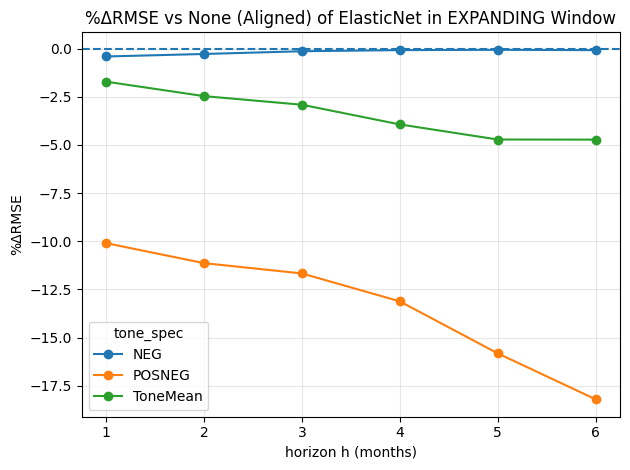

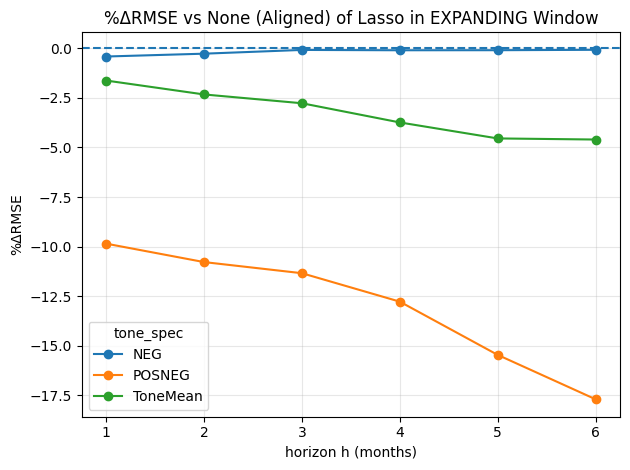

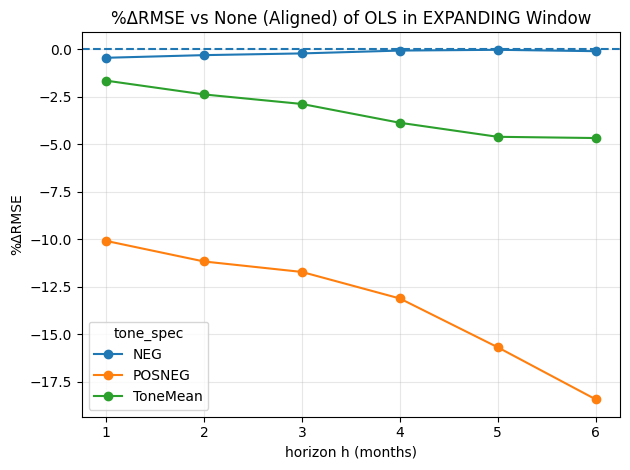

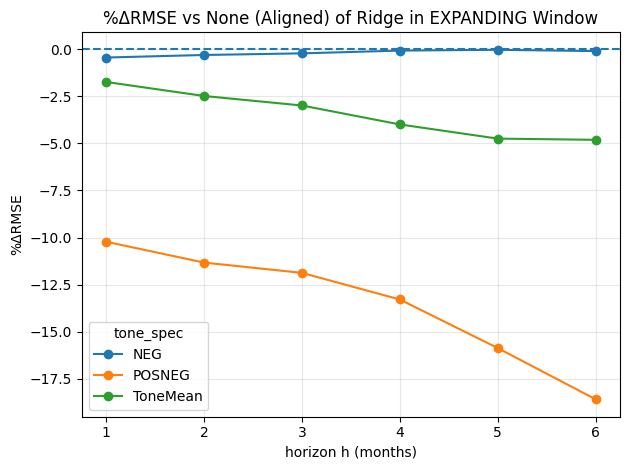

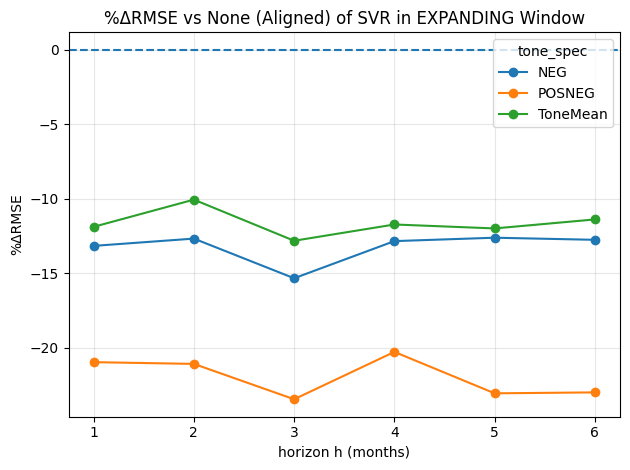

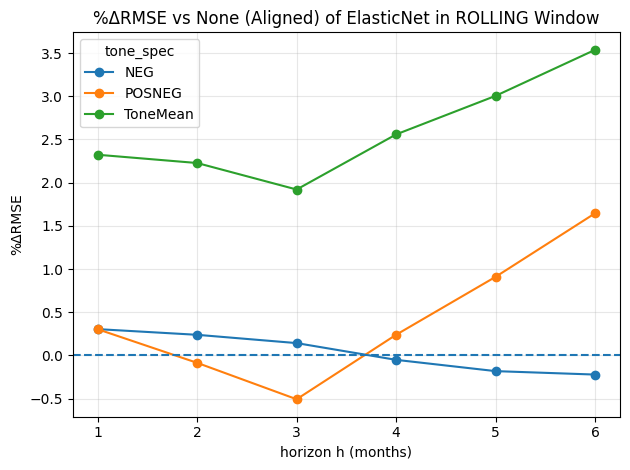

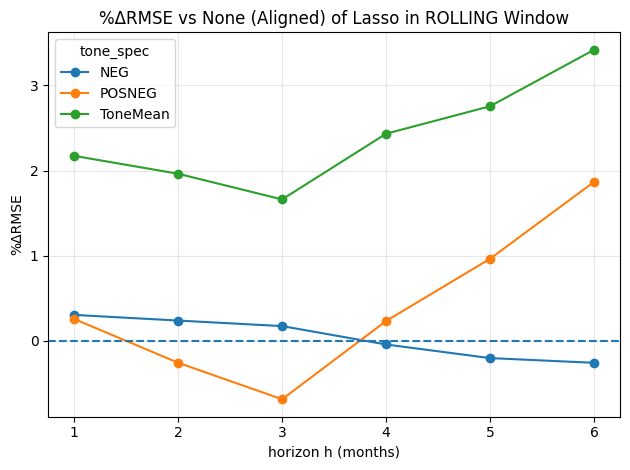

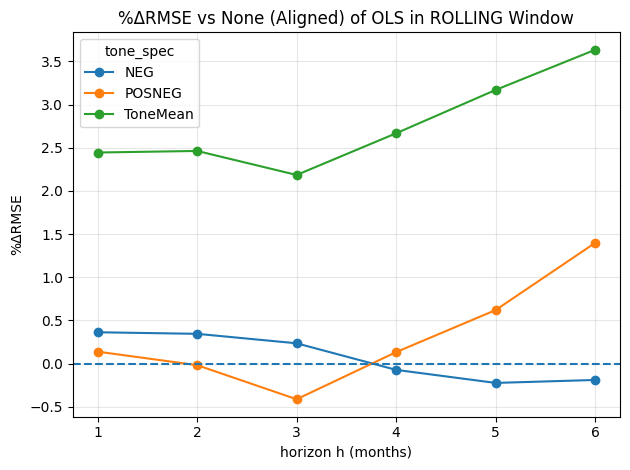

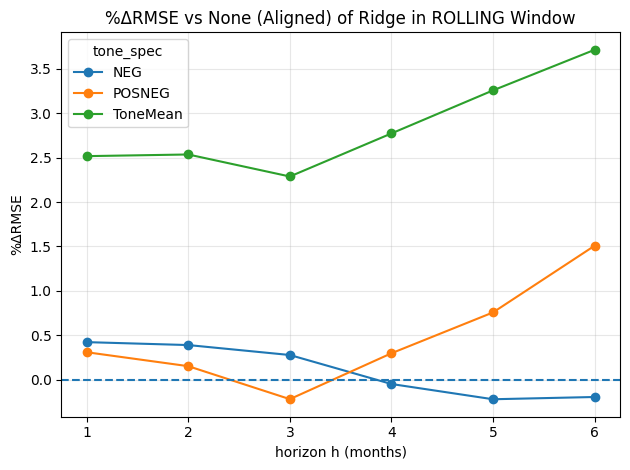

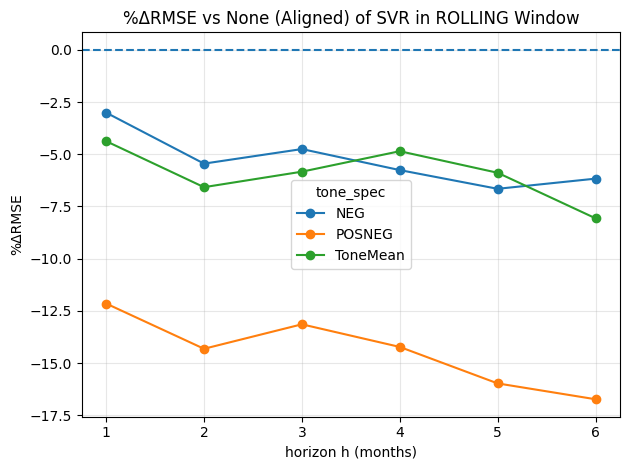

In [17]:
def plot_pct_improvement(acc2: pd.DataFrame):
    # exclude baseline because improvement is defined vs None
    df = acc2[acc2["tone_spec"] != "None"].copy()
    for scheme in df["window_scheme"].unique():
        sub = df[df["window_scheme"] == scheme]
        for model in sub["model"].unique():
            dfm = sub[sub["model"] == model].pivot_table(
                index="horizon_h", columns="tone_spec", values="pct_dRMSE_vs_none"
            ).sort_index()

            ax = dfm.plot(marker="o")
            ax.axhline(0.0, linestyle="--")
            ax.set_title(f"%ΔRMSE vs None (Aligned) of {model} in {scheme.upper()} Window")
            ax.set_xlabel("horizon h (months)")
            ax.set_ylabel("%ΔRMSE")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            filename = f"pct_drmse_aligned_{scheme}_{model}.png".replace(" ", "_")
            plt.savefig(os.path.join(OUT_DIR, filename), dpi=200)
            plt.show()

plot_pct_improvement(acc2)

In [18]:
# Merge aligned %ΔRMSE with CW/DM significance
acc_sig = acc.merge(
    sig[["window_scheme","horizon_h","model","tone_spec","CW_p_one_sided","DM_p_two_sided","MSFE_gain"]],
    on=["window_scheme","horizon_h","model","tone_spec"],
    how="left"
)

# Only tone specs (since %ΔRMSE and CW compare against None)
acc_sig = acc_sig[acc_sig["tone_spec"] != "None"].copy()

# Summarize across horizons
score = (
    acc_sig.groupby(["window_scheme","model","tone_spec"])
    .agg(
        mean_pct_dRMSE=("pct_dRMSE_vs_none","mean"),
        mean_MSFE_gain=("MSFE_gain","mean"),
        sig_share_10=("CW_p_one_sided", lambda s: float((s < 0.10).mean())),
        sig_share_05=("CW_p_one_sided", lambda s: float((s < 0.05).mean())),
        min_p=("CW_p_one_sided","min"),
        mean_p=("CW_p_one_sided","mean"),
        n_h=("horizon_h","nunique"),
    )
    .reset_index()
)

score.to_csv(os.path.join(OUT_DIR, "SCORE_model_tone_by_scheme.csv"), index=False)
score.head(20)

,window_scheme,model,tone_spec,mean_pct_dRMSE,mean_MSFE_gain,sig_share_10,sig_share_05,min_p,mean_p,n_h
0,expanding,ElasticNet,NEG,-0.175084,-0.003201,0.000000,0.000000,0.583904,0.748269,6
1,expanding,ElasticNet,POSNEG,-13.337318,-0.222296,0.000000,0.000000,0.966852,0.986406,6
2,expanding,ElasticNet,ToneMean,-3.412277,-0.052964,0.000000,0.000000,0.979574,0.984092,6
3,expanding,Lasso,NEG,-0.168184,-0.003069,0.000000,0.000000,0.680256,0.803222,6
4,expanding,Lasso,POSNEG,-12.988108,-0.216125,0.000000,0.000000,0.967016,0.986700,6
5,expanding,Lasso,ToneMean,-3.265036,-0.050551,0.000000,0.000000,0.976170,0.982351,6
6,expanding,OLS,NEG,-0.199696,-0.003675,0.000000,0.000000,0.525050,0.728220,6
7,expanding,OLS,POSNEG,-13.362838,-0.223893,0.000000,0.000000,0.960940,0.982427,6
8,expanding,OLS,ToneMean,-3.344949,-0.052122,0.000000,0.000000,0.976368,0.981856,6
9,expanding,Ridge,NEG,-0.194243,-0.003566,0.000000,0.000000,0.518442,0.720403,6


In [19]:
ALPHA = 0.05
SIG_SHARE_THRESHOLD = 0.50

sig_col = "sig_share_05" if ALPHA == 0.05 else "sig_share_10"

def pick_winner_for_scheme(score: pd.DataFrame, scheme: str) -> pd.DataFrame:
    sub = score[score["window_scheme"] == scheme].copy()

    # enforce significance share threshold
    sub = sub[sub[sig_col] >= SIG_SHARE_THRESHOLD].copy()
    if sub.empty:
        print(f"No candidates in {scheme} meet sig-share threshold. Lower SIG_SHARE_THRESHOLD or use ALPHA=0.10.")
        return sub

    # choose highest mean %ΔRMSE, then tie-break by mean p-value (smaller better)
    sub = sub.sort_values(["mean_pct_dRMSE", "mean_p"], ascending=[False, True]).head(1)
    return sub

winner_rolling = pick_winner_for_scheme(score, "rolling")
winner_expanding = pick_winner_for_scheme(score, "expanding")

print("WINNER — ROLLING")
display(winner_rolling)

print("WINNER — EXPANDING")
display(winner_expanding)

No candidates in expanding meet sig-share threshold. Lower SIG_SHARE_THRESHOLD or use ALPHA=0.10.
WINNER — ROLLING


,window_scheme,model,tone_spec,mean_pct_dRMSE,mean_MSFE_gain,sig_share_10,sig_share_05,min_p,mean_p,n_h
26,rolling,Ridge,ToneMean,2.847145,0.026736,0.833333,0.5,0.001448,0.05606,6


WINNER — EXPANDING


,window_scheme,model,tone_spec,mean_pct_dRMSE,mean_MSFE_gain,sig_share_10,sig_share_05,min_p,mean_p,n_h


In [20]:
def show_sig_details(winner_df: pd.DataFrame):
    if winner_df.empty:
        return
    scheme = winner_df.iloc[0]["window_scheme"]
    model = winner_df.iloc[0]["model"]
    tone  = winner_df.iloc[0]["tone_spec"]

    sub = sig[
        (sig["window_scheme"] == scheme) &
        (sig["model"] == model) &
        (sig["tone_spec"] == tone)
    ].sort_values("horizon_h")

    print(f"\nSignificance by horizon — {scheme.upper()} — {model} — {tone} vs None")
    display(sub[["horizon_h","MSFE_gain","CW_p_one_sided","DM_p_two_sided"]])

show_sig_details(winner_rolling)
show_sig_details(winner_expanding)


Significance by horizon — ROLLING — Ridge — ToneMean vs None


,horizon_h,MSFE_gain,CW_p_one_sided,DM_p_two_sided
101,1,0.024761,0.082072,0.224417
116,2,0.024416,0.109978,0.283594
131,3,0.022291,0.098265,0.264239
146,4,0.026425,0.036863,0.109015
161,5,0.030142,0.007733,0.020906
176,6,0.032382,0.001448,0.005010


In [21]:
ALPHA = 0.05                 # use 0.10 if you want looser significance
SIG_SHARE_THRESHOLD = 0.50   # e.g., must be significant in >= 3 of 6 horizons

# Merge aligned accuracy with CW p-values
acc_sig = acc.merge(
    sig[["window_scheme","horizon_h","model","tone_spec","CW_p_one_sided","MSFE_gain","DM_p_two_sided"]],
    on=["window_scheme","horizon_h","model","tone_spec"],
    how="left"
)

# Tone specs only (since %ΔRMSE and CW compare against None)
acc_sig = acc_sig[(acc_sig["window_scheme"] == "rolling") & (acc_sig["tone_spec"] != "None")].copy()

# Score across horizons
score_roll = (
    acc_sig.groupby(["model","tone_spec"])
    .agg(
        mean_pct_dRMSE=("pct_dRMSE_vs_none","mean"),
        sig_share=("CW_p_one_sided", lambda s: float((s < ALPHA).mean())),
        mean_p=("CW_p_one_sided","mean"),
        min_p=("CW_p_one_sided","min"),
        mean_MSFE_gain=("MSFE_gain","mean"),
        n_h=("horizon_h","nunique"),
    )
    .reset_index()
)

# Apply significance constraint, then choose best by %ΔRMSE
candidates = score_roll[score_roll["sig_share"] >= SIG_SHARE_THRESHOLD].copy()

if candidates.empty:
    print("No rolling candidates meet sig-share threshold. Lower SIG_SHARE_THRESHOLD or set ALPHA=0.10.")
    display(score_roll.sort_values("mean_pct_dRMSE", ascending=False).head(10))
else:
    winner_roll = candidates.sort_values(["mean_pct_dRMSE","mean_p"], ascending=[False, True]).head(1)
    print("ROLLING WINNER (best model + tone by %ΔRMSE with CW significance constraint):")
    display(winner_roll)

    # horizon-by-horizon CW/DM for the winner
    m, t = winner_roll.iloc[0]["model"], winner_roll.iloc[0]["tone_spec"]
    print(f"\nRolling significance by horizon — {m} — {t} vs None")
    detail = sig[(sig["window_scheme"]=="rolling") & (sig["model"]==m) & (sig["tone_spec"]==t)].sort_values("horizon_h")
    display(detail[["horizon_h","MSFE_gain","CW_p_one_sided","DM_p_two_sided"]])

ROLLING WINNER (best model + tone by %ΔRMSE with CW significance constraint):


,model,tone_spec,mean_pct_dRMSE,sig_share,mean_p,min_p,mean_MSFE_gain,n_h
11,Ridge,ToneMean,2.847145,0.5,0.05606,0.001448,0.026736,6



Rolling significance by horizon — Ridge — ToneMean vs None


,horizon_h,MSFE_gain,CW_p_one_sided,DM_p_two_sided
101,1,0.024761,0.082072,0.224417
116,2,0.024416,0.109978,0.283594
131,3,0.022291,0.098265,0.264239
146,4,0.026425,0.036863,0.109015
161,5,0.030142,0.007733,0.020906
176,6,0.032382,0.001448,0.005010


In [22]:
ALPHA = 0.05                 # use 0.10 if you want looser significance
SIG_SHARE_THRESHOLD = 0.50   # e.g., must be significant in >= 3 of 6 horizons

# Merge aligned accuracy with CW p-values
acc_sig = acc.merge(
    sig[["window_scheme","horizon_h","model","tone_spec","CW_p_one_sided","MSFE_gain","DM_p_two_sided"]],
    on=["window_scheme","horizon_h","model","tone_spec"],
    how="left"
)

# Tone specs only
acc_sig = acc_sig[(acc_sig["window_scheme"] == "expanding") & (acc_sig["tone_spec"] != "None")].copy()

# Score across horizons
score_exp = (
    acc_sig.groupby(["model","tone_spec"])
    .agg(
        mean_pct_dRMSE=("pct_dRMSE_vs_none","mean"),
        sig_share=("CW_p_one_sided", lambda s: float((s < ALPHA).mean())),
        mean_p=("CW_p_one_sided","mean"),
        min_p=("CW_p_one_sided","min"),
        mean_MSFE_gain=("MSFE_gain","mean"),
        n_h=("horizon_h","nunique"),
    )
    .reset_index()
)

# Apply significance constraint, then choose best by %ΔRMSE
candidates = score_exp[score_exp["sig_share"] >= SIG_SHARE_THRESHOLD].copy()

if candidates.empty:
    print("No expanding candidates meet sig-share threshold.")
    display(score_exp.sort_values("mean_pct_dRMSE", ascending=False).head(10))
else:
    winner_exp = candidates.sort_values(["mean_pct_dRMSE","mean_p"], ascending=[False, True]).head(1)
    print("EXPANDING WINNER (best model + tone by %ΔRMSE with CW significance constraint):")
    display(winner_exp)

    # horizon-by-horizon CW/DM for the winner
    m, t = winner_exp.iloc[0]["model"], winner_exp.iloc[0]["tone_spec"]
    print(f"\nExpanding significance by horizon — {m} — {t} vs None")
    detail = sig[(sig["window_scheme"]=="expanding") & (sig["model"]==m) & (sig["tone_spec"]==t)].sort_values("horizon_h")
    display(detail[["horizon_h","MSFE_gain","CW_p_one_sided","DM_p_two_sided"]])

No expanding candidates meet sig-share threshold.


,model,tone_spec,mean_pct_dRMSE,sig_share,mean_p,min_p,mean_MSFE_gain,n_h
3,Lasso,NEG,-0.168184,0.0,0.803222,0.680256,-0.003069,6
0,ElasticNet,NEG,-0.175084,0.0,0.748269,0.583904,-0.003201,6
9,Ridge,NEG,-0.194243,0.0,0.720403,0.518442,-0.003566,6
6,OLS,NEG,-0.199696,0.0,0.728220,0.525050,-0.003675,6
5,Lasso,ToneMean,-3.265036,0.0,0.982351,0.976170,-0.050551,6
8,OLS,ToneMean,-3.344949,0.0,0.981856,0.976368,-0.052122,6
2,ElasticNet,ToneMean,-3.412277,0.0,0.984092,0.979574,-0.052964,6
11,Ridge,ToneMean,-3.458686,0.0,0.983677,0.978783,-0.053809,6
14,SVR,ToneMean,-11.640469,0.0,0.487777,0.398489,-0.083026,6
4,Lasso,POSNEG,-12.988108,0.0,0.986700,0.967016,-0.216125,6


In [23]:
ALPHA = 0.05
SIG_SHARE_THRESHOLD = 0.50

# Merge aligned accuracy + CW pvals
acc_sig = acc.merge(
    sig[["window_scheme","horizon_h","model","tone_spec","CW_p_one_sided","MSFE_gain","DM_p_two_sided"]],
    on=["window_scheme","horizon_h","model","tone_spec"],
    how="left"
)

# Pick the WINNER in ROLLING by %ΔRMSE + significance share
roll_tone = acc_sig[(acc_sig["window_scheme"]=="rolling") & (acc_sig["tone_spec"]!="None")].copy()

score_roll = (
    roll_tone.groupby(["model","tone_spec"])
    .agg(
        mean_pct_dRMSE=("pct_dRMSE_vs_none","mean"),
        sig_share=("CW_p_one_sided", lambda s: float((s < ALPHA).mean())),
        mean_p=("CW_p_one_sided","mean"),
        n_h=("horizon_h","nunique"),
    )
    .reset_index()
)

cand = score_roll[score_roll["sig_share"] >= SIG_SHARE_THRESHOLD].copy()
if cand.empty:
    raise SystemExit("No rolling candidates meet sig-share threshold. Lower SIG_SHARE_THRESHOLD or use ALPHA=0.10.")

winner = cand.sort_values(["mean_pct_dRMSE","mean_p"], ascending=[False, True]).iloc[0]
WIN_MODEL, WIN_TONE = winner["model"], winner["tone_spec"]

print("ROLLING winner:", WIN_MODEL, "+", WIN_TONE)
display(pd.DataFrame([winner]))

# Build Benchmark A: SAME MODEL with tone_spec=None
benchA = (
    acc_sig[(acc_sig["window_scheme"]=="rolling") & (acc_sig["model"]==WIN_MODEL) & (acc_sig["tone_spec"]=="None")]
    .groupby(["window_scheme","model","tone_spec"])
    .agg(mean_rmse=("rmse_aligned","mean"), mean_mae=("mae_aligned","mean"))
    .reset_index()
)
# Winner overall RMSE (mean across horizons)
win_overall = (
    acc_sig[(acc_sig["window_scheme"]=="rolling") & (acc_sig["model"]==WIN_MODEL) & (acc_sig["tone_spec"]==WIN_TONE)]
    .groupby(["window_scheme","model","tone_spec"])
    .agg(mean_rmse=("rmse_aligned","mean"), mean_mae=("mae_aligned","mean"), mean_pct_dRMSE=("pct_dRMSE_vs_none","mean"))
    .reset_index()
)

# Build Benchmark B: BEST macro-only across all models
benchB = (
    acc_sig[(acc_sig["window_scheme"]=="rolling") & (acc_sig["tone_spec"]=="None")]
    .groupby(["model","tone_spec"])
    .agg(mean_rmse=("rmse_aligned","mean"))
    .reset_index()
    .sort_values("mean_rmse")
    .head(1)
)
BEST_NONE_MODEL = benchB.iloc[0]["model"]
BEST_NONE_RMSE  = float(benchB.iloc[0]["mean_rmse"])

# Combine + compute comparisons
benchA_rmse = float(benchA["mean_rmse"].iloc[0])
win_rmse = float(win_overall["mean_rmse"].iloc[0])

summary = pd.DataFrame([{
    "scheme": "rolling",
    "winner_model": WIN_MODEL,
    "winner_tone": WIN_TONE,
    "winner_mean_rmse": win_rmse,
    "benchA_same_model_None_rmse": benchA_rmse,
    "pct_dRMSE_vs_benchA": (benchA_rmse - win_rmse)/benchA_rmse*100 if benchA_rmse>0 else np.nan,
    "benchB_best_None_model": BEST_NONE_MODEL,
    "benchB_best_None_rmse": BEST_NONE_RMSE,
    "pct_dRMSE_vs_benchB": (BEST_NONE_RMSE - win_rmse)/BEST_NONE_RMSE*100 if BEST_NONE_RMSE>0 else np.nan,
}])

print("\nROLLING: Winner vs Benchmarks (mean across horizons)")
display(summary)

# CW/DM significance vs Benchmark A
detail = sig[(sig["window_scheme"]=="rolling") & (sig["model"]==WIN_MODEL) & (sig["tone_spec"]==WIN_TONE)].sort_values("horizon_h")
print(f"\nROLLING: Horizon-by-horizon significance — {WIN_MODEL} {WIN_TONE} vs None (same model)")
display(detail[["horizon_h","MSFE_gain","CW_p_one_sided","DM_p_two_sided"]])

print("CW significant share @5%:", float((detail["CW_p_one_sided"] < 0.05).mean()))
print("CW significant share @10%:", float((detail["CW_p_one_sided"] < 0.10).mean()))

ROLLING winner: Ridge + ToneMean


,model,tone_spec,mean_pct_dRMSE,sig_share,mean_p,n_h
11,Ridge,ToneMean,2.847145,0.5,0.05606,6



ROLLING: Winner vs Benchmarks (mean across horizons)


,scheme,winner_model,winner_tone,winner_mean_rmse,benchA_same_model_None_rmse,pct_dRMSE_vs_benchA,benchB_best_None_model,benchB_best_None_rmse,pct_dRMSE_vs_benchB
0,rolling,Ridge,ToneMean,0.672644,0.692293,2.838207,SVR,0.651694,-3.2147



ROLLING: Horizon-by-horizon significance — Ridge ToneMean vs None (same model)


,horizon_h,MSFE_gain,CW_p_one_sided,DM_p_two_sided
101,1,0.024761,0.082072,0.224417
116,2,0.024416,0.109978,0.283594
131,3,0.022291,0.098265,0.264239
146,4,0.026425,0.036863,0.109015
161,5,0.030142,0.007733,0.020906
176,6,0.032382,0.001448,0.005010


CW significant share @5%: 0.5
CW significant share @10%: 0.8333333333333334


In [24]:
# Build naive forecasts aligned to the SAME origin dates used in forecast_panel
# Requires df (full monthly data) and forecast_panel

def add_naive_forecasts(df: pd.DataFrame, panel: pd.DataFrame) -> pd.DataFrame:
    d = df[[DATE_COL, Y_COL]].copy().sort_values(DATE_COL)
    d = d.rename(columns={DATE_COL: "origin_date", Y_COL: "y_t"})

    # Merge y_t onto panel by origin_date
    p = panel.merge(d, on="origin_date", how="left")

    if FORECAST_DIFFERENCES:
        # Naive for differences: 0
        p["y_pred_naive"] = 0.0
    else:
        # Naive for levels: y_t
        p["y_pred_naive"] = p["y_t"]

    p["error_naive"] = p["y_true"] - p["y_pred_naive"]
    return p

panel_naive = add_naive_forecasts(df, forecast_panel)
panel_naive.head()

,window_scheme,horizon_h,model,tone_spec,origin_date,y_true,y_pred,error,y_t,y_pred_naive,error_naive
0,expanding,1,ElasticNet,NEG,2016-01-01,2.525040,3.454416,-0.929376,2.543428,2.543428,-0.018388
1,expanding,1,ElasticNet,NEG,2016-02-01,2.519768,3.617664,-1.097895,2.525040,2.525040,-0.005272
2,expanding,1,ElasticNet,NEG,2016-03-01,2.528319,3.220880,-0.692561,2.519768,2.519768,0.008551
3,expanding,1,ElasticNet,NEG,2016-04-01,2.523848,3.626085,-1.102237,2.528319,2.528319,-0.004471
4,expanding,1,ElasticNet,NEG,2016-05-01,2.525338,3.889900,-1.364562,2.523848,2.523848,0.001490


In [25]:
naive_metrics = (
    panel_naive.groupby(["window_scheme","horizon_h"])
    .agg(
        n=("error_naive","count"),
        naive_rmse=("error_naive", lambda e: float(np.sqrt(np.mean(np.square(e))))),
        naive_mae=("error_naive", lambda e: float(np.mean(np.abs(e)))),
    )
    .reset_index()
    .sort_values(["window_scheme","horizon_h"])
)

naive_metrics.to_csv(os.path.join(OUT_DIR, "NAIVE_metrics_by_scheme_horizon.csv"), index=False)
display(naive_metrics)

,window_scheme,horizon_h,n,naive_rmse,naive_mae
0,expanding,1,960,0.141757,0.087319
1,expanding,2,960,0.256871,0.170870
2,expanding,3,960,0.372622,0.254117
3,expanding,4,940,0.485941,0.336380
4,expanding,5,920,0.593123,0.418095
5,expanding,6,900,0.694225,0.495087
6,rolling,1,960,0.141757,0.087319
7,rolling,2,960,0.256871,0.170870
8,rolling,3,960,0.372622,0.254117
9,rolling,4,940,0.485941,0.336380


In [26]:
# Compute RMSE for each (scheme,h,model,tone) on exactly the same rows as naive
model_metrics = (
    panel_naive.groupby(["window_scheme","horizon_h","model","tone_spec"])
    .agg(
        n=("error","count"),
        rmse=("error", lambda e: float(np.sqrt(np.mean(np.square(e))))),
        mae=("error", lambda e: float(np.mean(np.abs(e)))),
    )
    .reset_index()
)

# Merge naive RMSE by scheme+horizon
cmp_naive = model_metrics.merge(
    naive_metrics[["window_scheme","horizon_h","naive_rmse","naive_mae"]],
    on=["window_scheme","horizon_h"],
    how="left"
)

cmp_naive["pct_improve_vs_naive_rmse"] = (cmp_naive["naive_rmse"] - cmp_naive["rmse"]) / cmp_naive["naive_rmse"] * 100.0
cmp_naive["rmse_ratio_vs_naive"] = cmp_naive["rmse"] / cmp_naive["naive_rmse"]

cmp_naive.to_csv(os.path.join(OUT_DIR, "COMPARE_vs_naive_by_scheme_horizon.csv"), index=False)
cmp_naive.head(20)

,window_scheme,horizon_h,model,tone_spec,n,rmse,mae,naive_rmse,naive_mae,pct_improve_vs_naive_rmse,rmse_ratio_vs_naive
0,expanding,1,ElasticNet,NEG,48,1.023604,0.936651,0.141757,0.087319,-622.082505,7.220825
1,expanding,1,ElasticNet,None,48,1.019424,0.930558,0.141757,0.087319,-619.133503,7.191335
2,expanding,1,ElasticNet,POSNEG,48,1.122344,1.020393,0.141757,0.087319,-691.736870,7.917369
3,expanding,1,ElasticNet,ToneMean,48,1.036922,0.946838,0.141757,0.087319,-631.477303,7.314773
4,expanding,1,Lasso,NEG,48,1.023458,0.938087,0.141757,0.087319,-621.979415,7.219794
5,expanding,1,Lasso,None,48,1.019285,0.932195,0.141757,0.087319,-619.035881,7.190359
6,expanding,1,Lasso,POSNEG,48,1.119710,1.020140,0.141757,0.087319,-689.878425,7.898784
7,expanding,1,Lasso,ToneMean,48,1.035813,0.947660,0.141757,0.087319,-630.695274,7.306953
8,expanding,1,OLS,NEG,48,1.027104,0.934861,0.141757,0.087319,-624.551482,7.245515
9,expanding,1,OLS,None,48,1.022482,0.928243,0.141757,0.087319,-621.291251,7.212913


In [27]:
# acc must contain: window_scheme, horizon_h, model, tone_spec, rmse_aligned
# If pct_dRMSE_vs_none already exists, you can skip.

import numpy as np
import pandas as pd

base_none = (
    acc[acc["tone_spec"] == "None"][["window_scheme","horizon_h","model","rmse_aligned"]]
    .rename(columns={"rmse_aligned": "rmse_none"})
)

acc_vs_none = acc.merge(base_none, on=["window_scheme","horizon_h","model"], how="left")
acc_vs_none["pct_dRMSE_vs_none"] = np.where(
    acc_vs_none["tone_spec"] == "None",
    np.nan,
    (acc_vs_none["rmse_none"] - acc_vs_none["rmse_aligned"]) / acc_vs_none["rmse_none"] * 100.0
)

acc_vs_none.head()

,window_scheme,horizon_h,model,tone_spec,n_common,rmse_none_aligned,rmse_aligned,mae_none_aligned,mae_aligned,pct_dRMSE_vs_none,rmse_none
0,expanding,1,ElasticNet,NEG,48,1.019424,1.023604,0.930558,0.936651,-0.410077,1.019424
1,expanding,1,ElasticNet,None,48,1.019424,1.019424,0.930558,0.930558,NaN,1.019424
2,expanding,1,ElasticNet,POSNEG,48,1.019424,1.122344,0.930558,1.020393,-10.095951,1.019424
3,expanding,1,ElasticNet,ToneMean,48,1.019424,1.036922,0.930558,0.946838,-1.716482,1.019424
4,expanding,1,Lasso,NEG,48,1.019285,1.023458,0.932195,0.938087,-0.409372,1.019285


In [28]:
def build_naive_rmse(df, forecast_panel):
    d = df[[DATE_COL, Y_COL]].copy().sort_values(DATE_COL)
    d = d.rename(columns={DATE_COL: "origin_date", Y_COL: "y_t"})

    p = forecast_panel.merge(d, on="origin_date", how="left")

    if FORECAST_DIFFERENCES:
        p["y_pred_naive"] = 0.0
    else:
        p["y_pred_naive"] = p["y_t"]

    p["error_naive"] = p["y_true"] - p["y_pred_naive"]

    naive = (
        p.groupby(["window_scheme","horizon_h"])
         .agg(naive_rmse=("error_naive", lambda e: float(np.sqrt(np.mean(e**2)))))
         .reset_index()
    )
    return naive

naive_tbl = build_naive_rmse(df, forecast_panel)
naive_tbl.head()

,window_scheme,horizon_h,naive_rmse
0,expanding,1,0.141757
1,expanding,2,0.256871
2,expanding,3,0.372622
3,expanding,4,0.485941
4,expanding,5,0.593123


In [29]:
# Compute model RMSE from forecast_panel (aligned)
model_rmse_tbl = (
    forecast_panel.groupby(["window_scheme","horizon_h","model","tone_spec"])
    .agg(rmse=("error", lambda e: float(np.sqrt(np.mean(np.square(e))))))
    .reset_index()
)

# Merge naive RMSE
acc_vs_naive = model_rmse_tbl.merge(naive_tbl, on=["window_scheme","horizon_h"], how="left")

# %ΔRMSE vs naive: positive means model beats naive
acc_vs_naive["pct_dRMSE_vs_naive"] = (
    (acc_vs_naive["naive_rmse"] - acc_vs_naive["rmse"]) / acc_vs_naive["naive_rmse"] * 100.0
)

acc_vs_naive.to_csv(os.path.join(OUT_DIR, "pct_dRMSE_vs_naive_by_scheme_horizon.csv"), index=False)
acc_vs_naive.head(20)

,window_scheme,horizon_h,model,tone_spec,rmse,naive_rmse,pct_dRMSE_vs_naive
0,expanding,1,ElasticNet,NEG,1.023604,0.141757,-622.082505
1,expanding,1,ElasticNet,None,1.019424,0.141757,-619.133503
2,expanding,1,ElasticNet,POSNEG,1.122344,0.141757,-691.736870
3,expanding,1,ElasticNet,ToneMean,1.036922,0.141757,-631.477303
4,expanding,1,Lasso,NEG,1.023458,0.141757,-621.979415
5,expanding,1,Lasso,None,1.019285,0.141757,-619.035881
6,expanding,1,Lasso,POSNEG,1.119710,0.141757,-689.878425
7,expanding,1,Lasso,ToneMean,1.035813,0.141757,-630.695274
8,expanding,1,OLS,NEG,1.027104,0.141757,-624.551482
9,expanding,1,OLS,None,1.022482,0.141757,-621.291251


In [30]:
# Overall mean %ΔRMSE vs None (tone specs only)
overall_vs_none = (
    acc_vs_none[acc_vs_none["tone_spec"] != "None"]
    .groupby(["window_scheme","model","tone_spec"])
    .agg(
        mean_pct_vs_none=("pct_dRMSE_vs_none","mean"),
        min_pct_vs_none=("pct_dRMSE_vs_none","min"),
        max_pct_vs_none=("pct_dRMSE_vs_none","max"),
        n_h=("horizon_h","nunique"),
    )
    .reset_index()
    .sort_values(["window_scheme","mean_pct_vs_none"], ascending=[True, False])
)

# Overall mean %ΔRMSE vs Naive (all specs incl None)
overall_vs_naive = (
    acc_vs_naive
    .groupby(["window_scheme","model","tone_spec"])
    .agg(
        mean_pct_vs_naive=("pct_dRMSE_vs_naive","mean"),
        min_pct_vs_naive=("pct_dRMSE_vs_naive","min"),
        max_pct_vs_naive=("pct_dRMSE_vs_naive","max"),
        n_h=("horizon_h","nunique"),
    )
    .reset_index()
    .sort_values(["window_scheme","mean_pct_vs_naive"], ascending=[True, False])
)

overall_vs_none.to_csv(os.path.join(OUT_DIR, "TABLE_overall_pct_dRMSE_vs_none.csv"), index=False)
overall_vs_naive.to_csv(os.path.join(OUT_DIR, "TABLE_overall_pct_dRMSE_vs_naive.csv"), index=False)

display(overall_vs_none.head(20))
display(overall_vs_naive.head(20))

,window_scheme,model,tone_spec,mean_pct_vs_none,min_pct_vs_none,max_pct_vs_none,n_h
3,expanding,Lasso,NEG,-0.168184,-0.409372,-0.070993,6
0,expanding,ElasticNet,NEG,-0.175084,-0.410077,-0.063172,6
9,expanding,Ridge,NEG,-0.194243,-0.440354,-0.030192,6
6,expanding,OLS,NEG,-0.199696,-0.451999,-0.032528,6
5,expanding,Lasso,ToneMean,-3.265036,-4.598768,-1.621531,6
8,expanding,OLS,ToneMean,-3.344949,-4.673930,-1.654381,6
2,expanding,ElasticNet,ToneMean,-3.412277,-4.724491,-1.716482,6
11,expanding,Ridge,ToneMean,-3.458686,-4.808869,-1.736773,6
14,expanding,SVR,ToneMean,-11.640469,-12.814495,-10.054802,6
4,expanding,Lasso,POSNEG,-12.988108,-17.704805,-9.852435,6


,window_scheme,model,tone_spec,mean_pct_vs_naive,min_pct_vs_naive,max_pct_vs_naive,n_h
17,expanding,SVR,None,-86.442109,-338.548400,20.369599,6
19,expanding,SVR,ToneMean,-108.047730,-390.648980,11.305101,6
16,expanding,SVR,NEG,-111.152552,-396.256554,10.215558,6
18,expanding,SVR,POSNEG,-126.679019,-430.476549,2.062272,6
1,expanding,ElasticNet,None,-195.748737,-619.133503,-11.470643,6
5,expanding,Lasso,None,-195.767552,-619.035881,-11.500783,6
13,expanding,Ridge,None,-196.108714,-620.104498,-11.461829,6
4,expanding,Lasso,NEG,-196.520836,-621.979415,-11.579941,6
0,expanding,ElasticNet,NEG,-196.526770,-622.082505,-11.560791,6
9,expanding,OLS,None,-196.602634,-621.291251,-11.627190,6


In [31]:
winner_vs_none = (
    overall_vs_none.sort_values(["window_scheme","mean_pct_vs_none"], ascending=[True, False])
    .groupby("window_scheme").head(1).reset_index(drop=True)
)
print("Best tone-augmented (model+tone) by mean %ΔRMSE vs None:")
display(winner_vs_none)

Best tone-augmented (model+tone) by mean %ΔRMSE vs None:


,window_scheme,model,tone_spec,mean_pct_vs_none,min_pct_vs_none,max_pct_vs_none,n_h
0,expanding,Lasso,NEG,-0.168184,-0.409372,-0.070993,6
1,rolling,Ridge,ToneMean,2.847145,2.287245,3.714202,6


In [32]:
winner_vs_naive = (
    overall_vs_naive.sort_values(["window_scheme","mean_pct_vs_naive"], ascending=[True, False])
    .groupby("window_scheme").head(1).reset_index(drop=True)
)
print("Best (model+tone) by mean %ΔRMSE vs Naive:")
display(winner_vs_naive)

Best (model+tone) by mean %ΔRMSE vs Naive:


,window_scheme,model,tone_spec,mean_pct_vs_naive,min_pct_vs_naive,max_pct_vs_naive,n_h
0,expanding,SVR,None,-86.442109,-338.548400,20.369599,6
1,rolling,SVR,None,-108.655800,-383.421039,12.348880,6
